# **Bias-variance visualisation in a univariate regression task**

#### Visualization of bias variance tradeoff for a set of polynomial fittings by using Monte Carlo simulation.
For each training set generated with Monte Carlo, a polinomial fitting is carried out and visualized. The distribution of the fitted models visualises the notion of bias and variance in regression.


 Enter to continue 


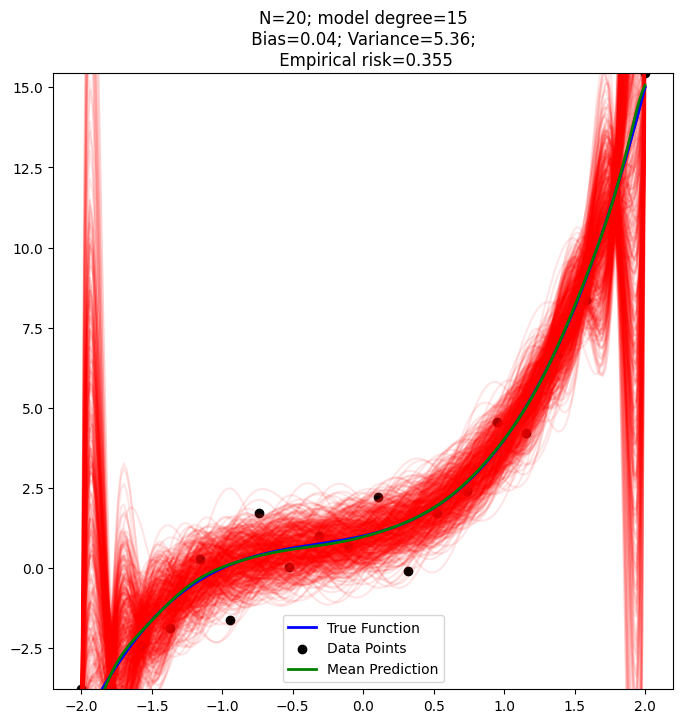

In [ ]:
# "INFOF422 Statistical foundations of machine learning" course
# biasvar_vis.py
# Author: G. Bontempi



import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from IPython.display import clear_output, display
import time

# Define the function f(x, ord) = 1 + x + x^2 + ... + x^ord
def f(x, ord):
    f_val = 1
    for i in range(1, ord + 1):
        f_val += x ** i
    return f_val



# Set random seed
np.random.seed(1)

n = 1
N = 20

x = np.linspace(-2, 2, N)
N = len(x)
sd_w = 0.75
O = 3
Y = f(x, ord=O) + np.random.normal(0, sd_w, size=N)
data_tr = np.column_stack((Y, x))
# %%

# %%


MaxDegree = 15 ## max degree of fitting polynomial

Remp = np.zeros(MaxDegree)  ## Empirical Risk
MSE_loo = np.zeros(MaxDegree) ## Leave-One-Out
x_ts = np.linspace(-2, 2, 200)

B2 = np.zeros(MaxDegree)  ## Squared Bias
V = np.zeros(MaxDegree)  ## Variance
PR = np.zeros(MaxDegree)
FPE = np.zeros(MaxDegree) ## FPE term



for r in range(1, MaxDegree + 1):
    X = np.column_stack([x ** ord for ord in range(1, r + 1)])
    X_ts = np.column_stack([x_ts ** ord for ord in range(1, r + 1)])
    p = r + 1
    Pr = []
    fig, ax = plt.subplots(figsize=(8, 8))
    for rr in range(1, 501):
        np.random.seed(rr)
        Y = f(x, ord=O) + np.random.normal(0, sd_w, size=N)
        DN = pd.DataFrame(X, columns=[f'x^{i}' for i in range(1, r + 1)])
        DN['Y'] = Y

        # Add constant term for intercept
        X_with_const = sm.add_constant(X)
        model = sm.OLS(Y, X_with_const).fit()
        sd_w_hat = np.sqrt(np.sum(model.resid ** 2) / (N - p))

        if rr == 1:
            Remp[r - 1] = np.mean(model.resid ** 2)
            PR[r - 1] = Remp[r - 1]
            FPE[r - 1] = Remp[r - 1] + 2 * sd_w_hat * p / N

        Y_ts = f(x_ts, ord=O)
        data_ts = pd.DataFrame(X_ts, columns=[f'x^{i}' for i in range(1, r + 1)])
        data_ts['Y'] = Y_ts

        if rr == 1:
            ax.plot(x_ts, Y_ts, label='True Function', color='blue', linewidth=2)
            ax.scatter(x, Y, label='Data Points', color='black')
            plt.ylim(min(Y), max(Y))
        pr = model.predict(sm.add_constant(X_ts))
        Pr.append(pr)
        ax.plot(x_ts, pr, color='red', alpha=0.1)

    Pr = np.array(Pr).T
    mean_pr = np.mean(Pr, axis=1)
    ax.plot(x_ts, Y_ts, color='blue', linewidth=2)
    ax.plot(x_ts, mean_pr, color='green', linewidth=2, label='Mean Prediction')

    bias = np.round(np.mean(np.abs(Y_ts - mean_pr)), 2)
    variance = np.round(np.mean(np.var(Pr, axis=1)), 2)
    Remp_val = np.round(Remp[r - 1], 3)

    plt.title(f"N={N}; model degree={r}\n Bias={bias}; Variance={variance}; \n Empirical risk={Remp_val}")
    B2[r - 1] = np.mean((Y_ts - mean_pr) ** 2)
    V[r - 1] = np.mean(np.var(Pr, axis=1))

    plt.legend()
    display(fig)
    clear_output(wait=True)  # Clear the output

    plt.close(fig)  # Close the figure
    time.sleep(0.1)
    input(" Enter to continue ")



plt.figure(figsize=(10, 6))
mR = MaxDegree
degrees = np.arange(1, mR + 1)

plt.plot(degrees[:MaxDegree], Remp[:MaxDegree], label='Remp', color='yellow', linewidth=3)
plt.plot(degrees[:MaxDegree], B2[:MaxDegree] + V[:MaxDegree], label='MSE', color='black', linewidth=3)
plt.plot(degrees[:MaxDegree], B2[:MaxDegree], label='Bias', color='green', linewidth=3)
plt.plot(degrees[:MaxDegree], V[:MaxDegree], label='Variance', color='red', linewidth=3)
plt.plot(degrees[:MaxDegree], PR[:MaxDegree], label='LOO', color='orange', linewidth=3)
plt.plot(degrees[:MaxDegree], FPE[:MaxDegree], label='FPE', color='cyan', linewidth=3)

plt.title("Bias-variance tradeoff")
plt.xlabel("Degree")
plt.ylabel("Error Metrics")
plt.legend(loc='upper right')
plt.ylim(0, 3)
plt.show()
